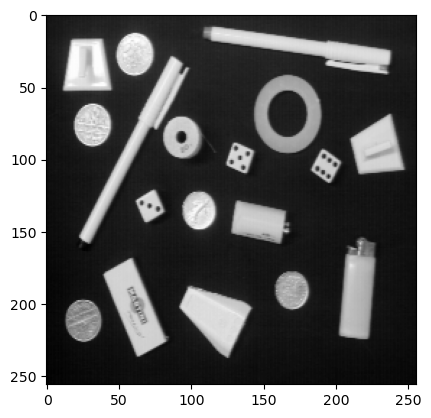

In [41]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/OBJECTS.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap="gray")
plt.show()

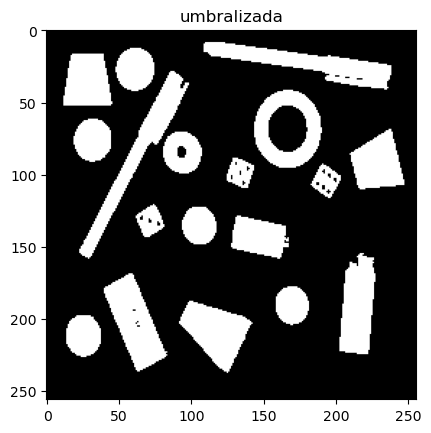

In [42]:
# Umbralice esta imagen para separar los objetos del fondo (umbral=70).

retval, umbralizada = cv2.threshold(image, 70, 255, cv2.THRESH_BINARY)

plt.imshow(umbralizada, cmap="gray")
plt.title("umbralizada")
plt.show()

2 26.862832121829882
3 33.680866130212806
5 54.25278906669805
6 26.23175126593998
7 35.79241376142726
8 27.657748640939687
12 23.98856636314297
13 26.253813230541255
14 23.373426783130235
15 27.175635294132753
16 23.349043323226613
17 36.531860859320055
18 24.62337713684165


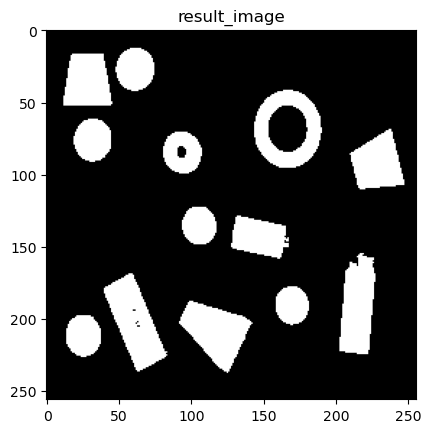

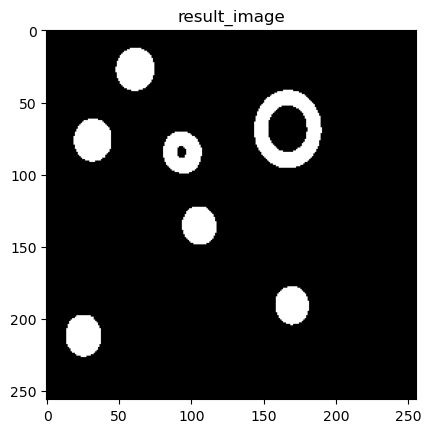

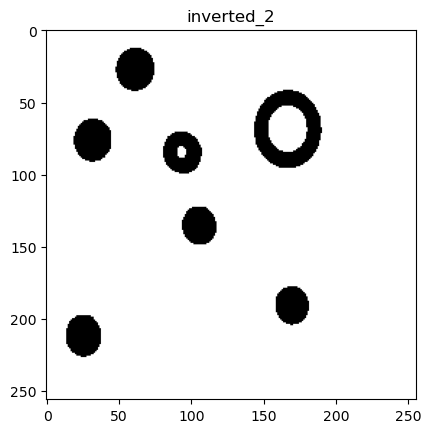

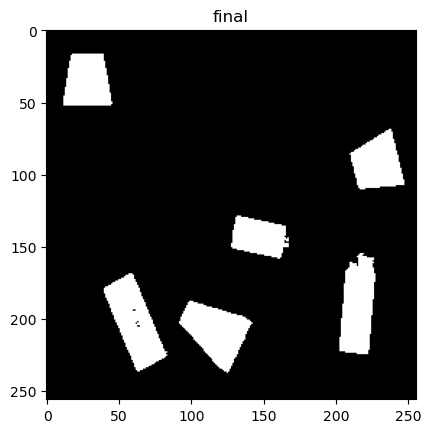

In [63]:
# Etiquetado de objetos

from skimage.measure import label, regionprops
import numpy as np

connected_components = label(umbralizada, background=0, connectivity=2)

regions = regionprops(connected_components)

objetos_interes = []
result_image = np.zeros_like(umbralizada)

for r in regions:
    if r.axis_minor_length >= 22:
        result_image[connected_components == r.label] = 255
        print(r.label, r.axis_minor_length)
        objetos_interes.append(r)


plt.imshow(result_image, cmap="gray", vmin=0, vmax=255)
plt.title("result_image")
plt.show()

result_image2 = np.zeros_like(umbralizada)
for r in objetos_interes:
    if r.axis_minor_length >=38:
        result_image2[connected_components == r.label] = 255
    if r.axis_major_length <=40:
        result_image2[connected_components == r.label] = 255

plt.imshow(result_image2, cmap="gray", vmin=0, vmax=255)
plt.title("result_image")
plt.show()

inverted_2 = cv2.bitwise_not(result_image2)
plt.imshow(inverted_2, cmap="gray", vmin=0, vmax=255)
plt.title("inverted_2")
plt.show()

final = cv2.bitwise_and(result_image, inverted_2)
plt.imshow(final, cmap="gray", vmin=0, vmax=255)
plt.title("final")
plt.show()